# Analyse der Rabatt-Authentizität

Dieses Notebook untersucht die bei **Tennistown**, **Tennis-Heine** und **Tennis-Point** beobachteten Rabattdarstellungen im Erhebungszeitraum vom 14.06.2026 bis zum 17.07.2026.

Im Mittelpunkt stehen:

- die Abdeckung der erfassten Streichpreise und unverbindlichen Preisempfehlungen
- die Höhe der gegenüber diesen Referenzpreisen dargestellten Preisnachlässe
- die Frage, ob ein ausgewiesener Streichpreis im Erhebungszeitraum zuvor tatsächlich als `current_price` derselben Produktvariante beobachtet wurde

Der zum jeweiligen Abruf aktuell angezeigte Preis ist in `current_price` gespeichert. `regular_price` enthält einen gegebenenfalls ausgewiesenen Streichpreis, während `msrp_price` die unverbindliche Preisempfehlung des Herstellers bezeichnet. Da diese beiden Referenzpreise eine unterschiedliche Bedeutung besitzen, werden sie getrennt ausgewertet.

Produktvarianten werden innerhalb eines Händlers über die Kombination aus `product_url_key` und `reference_variant` verfolgt. Eine normalisierte GTIN ist für diese händlerinterne Analyse nicht erforderlich.

> **Hinweis zur Interpretation:** Die Analyse ermöglicht ausschließlich eine datenbasierte Plausibilitätsprüfung der beobachteten Rabattdarstellungen. Wurde ein ausgewiesener Streichpreis im begrenzten Erhebungszeitraum nicht zuvor als `current_price` beobachtet, belegt dies weder eine unzulässige Rabattdarstellung noch einen Scheinrabatt. Der betreffende Preis kann bereits vor Beginn des Erhebungszeitraums gegolten haben oder auf einer anderen, nicht erfassten Vergleichsgrundlage beruhen.
>
> Die Preisangaben werden unabhängig vom Verfügbarkeitsstatus ausgewertet. Sie werden als beobachtete Angaben der Produktseite und nicht als Nachweis eines zum jeweiligen Zeitpunkt tatsächlich kaufbaren Angebots interpretiert.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Einheitliches Erscheinungsbild für alle Visualisierungen festlegen
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
# --- PFAD-KONFIGURATION ---

# Verzeichnis mit dem aufbereiteten Datenbestand
data_processed_dir = '../data/processed'

# Dateiname der aufbereiteten Datentabelle
processed_file_name = 'tennis_data_prepared.csv'

# Vollständigen Dateipfad erzeugen
processed_file_path = os.path.join(data_processed_dir, processed_file_name)

## Aufbereiteten Datenbestand einlesen

Die in `02_data_preparation` erzeugte Datei `tennis_data_prepared.csv` wird als Grundlage der Rabattanalyse eingelesen.

Die Identifikatoren `product_url_key`, `ean` und `gtin_normalized` werden als Zeichenfolgen geladen. Dadurch bleiben ihre Formate und mögliche führende Nullen erhalten. `timestamp` und `run_date` werden als Datumswerte eingelesen, damit die Preisangaben später chronologisch ausgewertet werden können.

In [3]:
if not os.path.exists(processed_file_path):
    raise FileNotFoundError(f'Die Datei "{processed_file_path}" wurde nicht gefunden.')

df_tennis_data = pd.read_csv(
    processed_file_path,
    encoding='utf-8',
    dtype={
        'product_url_key': 'string',
        'ean': 'string',
        'gtin_normalized': 'string'
    },
    parse_dates=[
        'timestamp',
        'run_date'
    ]
)

print('--- AUFBEREITETER DATENBESTAND EINGELESEN ---')
print(f'Beobachtungen: {len(df_tennis_data)}')
print(f'Spalten: {len(df_tennis_data.columns)}')
print(f'Erhebungszeitraum: {df_tennis_data["timestamp"].min():%d.%m.%Y} bis {df_tennis_data["timestamp"].max():%d.%m.%Y}')

--- AUFBEREITETER DATENBESTAND EINGELESEN ---
Beobachtungen: 87609
Spalten: 19
Erhebungszeitraum: 14.06.2026 bis 17.07.2026


In [4]:
# Beispielhafte Ausgabe der ersten Produktbeobachtungen
display(df_tennis_data.head())

,retailer,timestamp,run_date,run,source_file,category,gender,brand,name,reference_variant,product_url_key,ean,gtin_normalized,current_price,regular_price,msrp_price,currency,availability,url
0,Tennistown,2026-06-14 10:13:49,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Boom MP Neon 100in/295g/Tu...,L2,95421,0198772103576,00198772103576,161.96,179.95,260.00,€,in_stock,https://www.tennistown.de/product_info.php?cPa...
1,Tennistown,2026-06-14 10:13:49,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Boom MP Neon 100in/295g/Tu...,L3,95421,0198772103583,00198772103583,161.96,179.95,260.00,€,in_stock,https://www.tennistown.de/product_info.php?cPa...
2,Tennistown,2026-06-14 10:13:54,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Gravity Tour 100in/305g/Tu...,L2,69457,<NA>,<NA>,151.20,168.00,280.00,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...
3,Tennistown,2026-06-14 10:13:54,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Gravity Tour 100in/305g/Tu...,L3,69457,<NA>,<NA>,151.20,168.00,280.00,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...
4,Tennistown,2026-06-14 10:13:57,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Yonex,Yonex Tennisschläger EZone (8th Gen.) 98in/305...,L2,87664,<NA>,<NA>,244.90,NaN,279.95,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...


## Abdeckung der Preisfelder untersuchen

Zunächst wird geprüft, in welchem Umfang die drei für die Rabattanalyse relevanten Preisfelder bei den einzelnen Händlern vorhanden sind.

Liegt für eine Produktbeobachtung neben dem `current_price` kein `regular_price` vor, wurde auf der Produktseite kein zusätzlicher Streichpreis angezeigt. Diese Beobachtung enthält daher keine über einen Streichpreis kommunizierte Rabattdarstellung. Ist dagegen zusätzlich ein `regular_price` vorhanden, wird der aktuelle Preis auf der Produktseite einem Streichpreis gegenübergestellt. Ob dieser Streichpreis tatsächlich über dem `current_price` liegt, wird im folgenden Abschnitt gesondert kontrolliert.

Ein fehlender `msrp_price` bedeutet entsprechend, dass keine separate unverbindliche Preisempfehlung erfasst wurde. Die ausgewiesenen Anzahlen beziehen sich auf einzelne Produktbeobachtungen. Wiederholte Beobachtungen derselben Produktvariante über mehrere Abrufe werden daher mehrfach berücksichtigt.

In [5]:
# --- ABDECKUNG DER PREISFELDER ZUSAMMENFASSEN ---

# Einheitliche Reihenfolge der Händler festlegen
retailer_order = ['Tennistown', 'Tennis-Heine', 'Tennis-Point']

# Vorhandene Preisangaben je Händler zählen
df_price_coverage_overview = (
    df_tennis_data
    .groupby('retailer', sort=False)
    .agg(
        Observations=('current_price', 'size'),
        Current_price=('current_price', 'count'),
        Regular_price=('regular_price', 'count'),
        MSRP_price=('msrp_price', 'count')
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Current_price': 'Current price',
        'Regular_price': 'Regular price',
        'MSRP_price': 'MSRP price'
    })
)

# Anteil der Beobachtungen mit vorhandenem aktuellem Preis berechnen
df_price_coverage_overview['Current price coverage (%)'] = (
    df_price_coverage_overview['Current price']
    / df_price_coverage_overview['Observations']
    * 100
).round(1)

# Anteil der Beobachtungen mit vorhandenem Streichpreis berechnen
df_price_coverage_overview['Regular price coverage (%)'] = (
    df_price_coverage_overview['Regular price']
    / df_price_coverage_overview['Observations']
    * 100
).round(1)

# Anteil der Beobachtungen mit vorhandener unverbindlicher Preisempfehlung berechnen
df_price_coverage_overview['MSRP price coverage (%)'] = (
    df_price_coverage_overview['MSRP price']
    / df_price_coverage_overview['Observations']
    * 100
).round(1)

# Gewünschte Spaltenreihenfolge festlegen
df_price_coverage_overview = df_price_coverage_overview[[
    'Retailer',
    'Observations',
    'Current price',
    'Current price coverage (%)',
    'Regular price',
    'Regular price coverage (%)',
    'MSRP price',
    'MSRP price coverage (%)'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_price_coverage_overview = (
    df_price_coverage_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- ABDECKUNG DER PREISFELDER ---')
print('Zeigt die Anzahl vorhandener aktueller Preise, Streichpreise und unverbindlicher Preisempfehlungen je Händler an.\n')

display(df_price_coverage_overview)

--- ABDECKUNG DER PREISFELDER ---
Zeigt die Anzahl vorhandener aktueller Preise, Streichpreise und unverbindlicher Preisempfehlungen je Händler an.



,Retailer,Observations,Current price,Current price coverage (%),Regular price,Regular price coverage (%),MSRP price,MSRP price coverage (%)
0,Tennistown,39394,39394,100.0,9290,23.6,39394,100.0
1,Tennis-Heine,27458,27458,100.0,27458,100.0,25178,91.7
2,Tennis-Point,20757,20757,100.0,20124,97.0,0,0.0


Für sämtliche Produktbeobachtungen liegt ein `current_price` vor. Die Abdeckung der beiden Referenzpreisfelder unterscheidet sich dagegen deutlich zwischen den Händlern.

Bei Tennistown ist für 9.290 der 39.394 Beobachtungen ein `regular_price` vorhanden. Dies entspricht einer Abdeckung von 23,6 %. Eine unverbindliche Preisempfehlung liegt dagegen für sämtliche Tennistown-Beobachtungen vor.

Tennis-Heine weist bei allen 27.458 Beobachtungen einen `regular_price` aus. Ein `msrp_price` ist für 25.178 Beobachtungen und damit für 91,7 % des Händlerdatensatzes vorhanden.

Bei Tennis-Point liegt für 20.124 der 20.757 Beobachtungen ein `regular_price` vor. Dies entspricht einer Abdeckung von 97,0 %. Dabei handelt es sich um den auf der Produktseite ausgewiesenen Streichpreis. Ob dieser Preis der unverbindlichen Preisempfehlung entspricht, lässt sich anhand der erfassten Daten nicht bestimmen. Eine separate UVP steht für Tennis-Point in den erhobenen Daten nicht zur Verfügung.

Aufgrund dieser unterschiedlichen Datenverfügbarkeit werden Streichpreise und unverbindliche Preisempfehlungen im weiteren Verlauf getrennt betrachtet.

## Verhältnis zwischen aktuellem Preis und Referenzpreis prüfen

Vor der Berechnung der dargestellten Preisnachlässe wird geprüft, in welchem Verhältnis die erfassten Referenzpreise zum jeweiligen aktuell angezeigten Preis stehen.

Liegt der `regular_price` oder `msrp_price` über dem aktuellen Preis, ergibt sich gegenüber dem jeweiligen Referenzwert ein positiver Preisnachlass. Entspricht der Referenzpreis dem aktuellen Preis, besteht gegenüber diesem Wert kein Preisnachlass. Ein Referenzpreis unterhalb des aktuellen Preises wäre dagegen widersprüchlich und würde bei einer unmittelbaren Rabattberechnung zu einem negativen Wert führen.

In [6]:
# --- VERHÄLTNIS ZWISCHEN AKTUELLEM PREIS UND REFERENZPREIS PRÜFEN ---

# Zu untersuchende Referenzpreisfelder und verständliche Bezeichnungen festlegen
reference_price_columns = {
    'regular_price': 'Regular price',
    'msrp_price': 'MSRP price'
}

price_relationship_list = []

# Preisverhältnisse für jeden Händler und Referenzpreistyp getrennt auswerten
for retailer in retailer_order:
    for reference_price_column, reference_price_label in reference_price_columns.items():

        # Beobachtungen des aktuellen Händlers mit vorhandenem Referenzpreis auswählen
        reference_price_mask = (
            df_tennis_data['retailer'].eq(retailer)
            & df_tennis_data[reference_price_column].notna()
        )

        df_reference_prices = df_tennis_data.loc[reference_price_mask, ['current_price', reference_price_column]]

        # Anzahl der Beobachtungen nach dem Verhältnis der beiden Preise zusammenfassen
        price_relationship_list.append({
            'Retailer': retailer,
            'Reference price type': reference_price_label,
            'Reference price observations': len(df_reference_prices),
            'Above current price': int(df_reference_prices[reference_price_column].gt(df_reference_prices['current_price']).sum()),
            'Equal to current price': int(df_reference_prices[reference_price_column].eq(df_reference_prices['current_price']).sum()),
            'Below current price': int(df_reference_prices[reference_price_column].lt(df_reference_prices['current_price']).sum())
        })

# Ergebnisse als gemeinsame Übersicht speichern
df_reference_price_relationship_overview = pd.DataFrame(price_relationship_list)

print('--- VERHÄLTNIS ZWISCHEN AKTUELLEM PREIS UND REFERENZPREIS ---')
print('Zeigt, ob die erfassten Streichpreise und unverbindlichen Preisempfehlungen über, auf oder unter dem aktuellen Preis liegen.\n')

display(df_reference_price_relationship_overview)

--- VERHÄLTNIS ZWISCHEN AKTUELLEM PREIS UND REFERENZPREIS ---
Zeigt, ob die erfassten Streichpreise und unverbindlichen Preisempfehlungen über, auf oder unter dem aktuellen Preis liegen.



,Retailer,Reference price type,Reference price observations,Above current price,Equal to current price,Below current price
0,Tennistown,Regular price,9290,9290,0,0
1,Tennistown,MSRP price,39394,39338,56,0
2,Tennis-Heine,Regular price,27458,27458,0,0
3,Tennis-Heine,MSRP price,25178,25178,0,0
4,Tennis-Point,Regular price,20124,20124,0,0
5,Tennis-Point,MSRP price,0,0,0,0


Sämtliche bei Tennistown, Tennis-Heine und Tennis-Point erfassten Streichpreise liegen über dem jeweiligen `current_price`.

Bei Tennistown liegen 39.338 der 39.394 erfassten unverbindlichen Preisempfehlungen über dem aktuellen Preis. In 56 Beobachtungen entsprechen sich `msrp_price` und `current_price`, sodass gegenüber der UVP kein Preisnachlass besteht. Bei Tennis-Heine liegen sämtliche vorhandenen unverbindlichen Preisempfehlungen über dem aktuellen Preis. Für Tennis-Point steht kein separater `msrp_price` zur Verfügung.

In keiner Produktbeobachtung liegt ein erfasster Streichpreis oder eine unverbindliche Preisempfehlung unter dem jeweiligen `current_price`. Die Preisfelder weisen damit keine widersprüchlichen Verhältnisse auf.

## Höhe der dargestellten Preisnachlässe untersuchen

Nach der formalen Prüfung der Preisverhältnisse wird berechnet, wie groß die Differenz zwischen dem jeweiligen Referenzpreis und dem `current_price` ausfällt.

Der absolute Preisnachlass in Euro ergibt sich aus der Differenz zwischen Referenzpreis und aktuellem Preis. Für den prozentualen Preisnachlass wird diese Differenz durch den jeweiligen Referenzpreis geteilt.

Die Berechnungen werden ausschließlich für Beobachtungen durchgeführt, bei denen der jeweilige Referenzpreis über dem `current_price` liegt. Beobachtungen mit identischem Referenz- und aktuellem Preis entsprechen einem Preisnachlass von 0 % und werden nicht als Rabattbeobachtungen gezählt. Streichpreise und unverbindliche Preisempfehlungen werden weiterhin getrennt betrachtet. Ein Preisnachlass gegenüber einem Streichpreis beschreibt die auf der Produktseite dargestellte Reduzierung. Der Abstand zur UVP stellt dagegen lediglich einen Vergleich mit der Herstellerempfehlung dar. 

Die Auswertung erfolgt auf Ebene einzelner Produktbeobachtungen. Wiederholte Beobachtungen derselben Produktvariante können daher mehrfach in die Kennzahlen eingehen.

In [7]:
# --- PREISNACHLÄSSE GEGENÜBER DEN REFERENZPREISEN BERECHNEN ---

# Kopie des Datenbestands für die Rabattanalyse erstellen
df_discount_data = df_tennis_data.copy()

# Absoluten Preisnachlass gegenüber dem Streichpreis berechnen
df_discount_data['regular_discount_eur'] = (
    df_discount_data['regular_price'] - df_discount_data['current_price']
).where(
    df_discount_data['regular_price'].gt(df_discount_data['current_price'])
).round(2)

# Prozentualen Preisnachlass gegenüber dem Streichpreis berechnen
df_discount_data['regular_discount_pct'] = (df_discount_data['regular_discount_eur'] / df_discount_data['regular_price'] * 100).round(2)

# Absoluten Preisabstand gegenüber der unverbindlichen Preisempfehlung berechnen
df_discount_data['msrp_discount_eur'] = (
    df_discount_data['msrp_price'] - df_discount_data['current_price']
).where(
    df_discount_data['msrp_price'].gt(df_discount_data['current_price'])
).round(2)

# Prozentualen Preisabstand gegenüber der unverbindlichen Preisempfehlung berechnen
df_discount_data['msrp_discount_pct'] = (df_discount_data['msrp_discount_eur'] / df_discount_data['msrp_price'] * 100).round(2)

In [8]:
# --- HÖHE DER PREISNACHLÄSSE JE HÄNDLER ZUSAMMENFASSEN ---

# Zuordnung der Referenzpreistypen zu den berechneten Nachlassspalten festlegen
discount_column_definitions = {
    'Regular price': ('regular_discount_eur', 'regular_discount_pct'),
    'MSRP price': ('msrp_discount_eur', 'msrp_discount_pct')
}

discount_amount_overview_list = []

# Preisnachlässe für jeden Händler und Referenzpreistyp getrennt auswerten
for retailer in retailer_order:
    for reference_price_type, discount_columns in discount_column_definitions.items():
        discount_eur_column, discount_pct_column = discount_columns

        # Beobachtungen mit einem positiven Preisnachlass auswählen
        df_reference_discounts = df_discount_data.loc[df_discount_data['retailer'].eq(retailer) & df_discount_data[discount_pct_column].notna()]

        # Anzahl und Median der beobachteten Preisnachlässe sichern
        discount_amount_overview_list.append({
            'Retailer': retailer,
            'Reference price type': reference_price_type,
            'Discount observations': len(df_reference_discounts),
            'Median discount (€)': df_reference_discounts[discount_eur_column].median(),
            'Median discount (%)': df_reference_discounts[discount_pct_column].median()
        })

# Ergebnisse als gemeinsame Übersicht speichern
df_discount_amount_overview = pd.DataFrame(discount_amount_overview_list)

# Preiskennzahlen auf zwei Nachkommastellen runden
df_discount_amount_overview = df_discount_amount_overview.round({
    'Median discount (€)': 2,
    'Median discount (%)': 2
})

print('--- HÖHE DER DARGESTELLTEN PREISNACHLÄSSE ---')
print('Zeigt die Anzahl und den Median der positiven Preisnachlässe je Händler und Referenzpreistyp an.\n')

display(df_discount_amount_overview)

--- HÖHE DER DARGESTELLTEN PREISNACHLÄSSE ---
Zeigt die Anzahl und den Median der positiven Preisnachlässe je Händler und Referenzpreistyp an.



,Retailer,Reference price type,Discount observations,Median discount (€),Median discount (%)
0,Tennistown,Regular price,9290,13.00,10.00
1,Tennistown,MSRP price,39338,53.50,33.38
2,Tennis-Heine,Regular price,27458,80.05,36.24
3,Tennis-Heine,MSRP price,25178,83.49,36.06
4,Tennis-Point,Regular price,20124,65.05,32.03
5,Tennis-Point,MSRP price,0,NaN,NaN


Bei Tennistown beträgt der mediane Preisnachlass gegenüber dem ausgewiesenen Streichpreis 13,00 € beziehungsweise 10,00 %. Gegenüber der unverbindlichen Preisempfehlung liegt der Median mit 53,50 € beziehungsweise 33,38 % deutlich höher. Die 56 Tennistown-Beobachtungen, bei denen `msrp_price` und `current_price` identisch sind, gehen nicht in diese Berechnung ein, da gegenüber der UVP kein positiver Preisnachlass besteht.

Tennis-Heine weist gegenüber dem Streichpreis einen medianen Preisnachlass von 80,05 € beziehungsweise 36,24 % auf. Der mediane Abstand zur UVP fällt mit 83,49 € beziehungsweise 36,06 % ähnlich aus.

Bei Tennis-Point beträgt der mediane Preisnachlass gegenüber dem ausgewiesenen Streichpreis 65,05 € beziehungsweise 32,03 %. Eine Berechnung gegenüber der UVP ist nicht möglich. Die Ergebnisse zeigen deutliche Unterschiede zwischen den beobachteten Referenzpreisdarstellungen.

Die medianen prozentualen Preisnachlässe werden ergänzend in einem gruppierten Balkendiagramm gegenübergestellt. Dadurch lassen sich die Unterschiede zwischen den Händlern und den beiden Referenzpreistypen unmittelbar vergleichen.

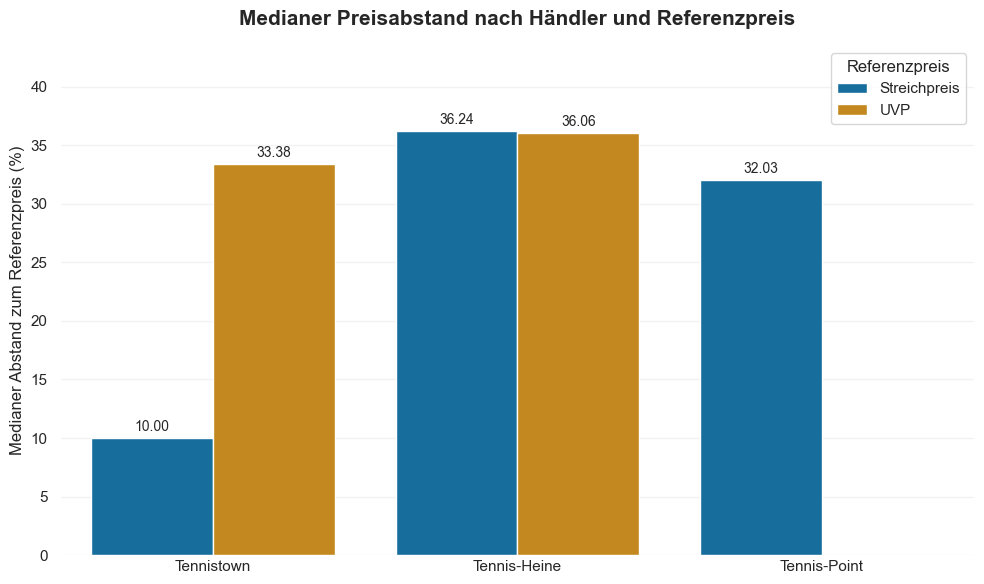

In [9]:
# --- MEDIANE PROZENTUALE PREISNACHLÄSSE VISUALISIEREN ---

# Nur Händler und Referenzpreistypen mit beobachteten Preisnachlässen berücksichtigen
df_discount_median_plot = (
    df_discount_amount_overview
    .loc[df_discount_amount_overview['Discount observations'].gt(0)]
    .copy()
)

# Referenzpreistypen für die deutschsprachige Visualisierung umbenennen
df_discount_median_plot['Reference price type'] = (
    df_discount_median_plot['Reference price type']
    .replace({'Regular price': 'Streichpreis', 'MSRP price': 'UVP'})
)

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))

# Gruppiertes Balkendiagramm der medianen Preisnachlässe erzeugen
sns.barplot(
    data=df_discount_median_plot,
    x='Retailer',
    y='Median discount (%)',
    hue='Reference price type',
    order=retailer_order,
    hue_order=['Streichpreis', 'UVP'],
    palette='colorblind',
    errorbar=None,
    ax=ax
)

# Prozentwerte oberhalb der Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Diagramm beschriften
ax.set_title('Medianer Preisabstand nach Händler und Referenzpreis', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Medianer Abstand zum Referenzpreis (%)')

# Achsenmarkierungen unter den Balken entfernen
ax.tick_params(axis='x', length=0)

# Legende und Gitternetz anpassen
ax.legend(title='Referenzpreis')
ax.grid(axis='y', alpha=0.25)

# Platz für die Beschriftungen oberhalb der Balken schaffen
ax.set_ylim(0, df_discount_median_plot['Median discount (%)'].max() * 1.2)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Die dargestellten Abstände beschreiben die Höhe der beobachteten Preisreduzierungen, erlauben für sich genommen jedoch noch keine Beurteilung ihrer Authentizität. Hierfür wird im folgenden Abschnitt geprüft, ob die ausgewiesenen Streichpreise zuvor tatsächlich als `current_price` derselben Produktvariante beobachtet wurden.

## Historische Plausibilität der Streichpreise prüfen

Im nächsten Schritt wird untersucht, ob ein ausgewiesener Streichpreis (`regular_price`) bei derselben Produktvariante und demselben Händler bereits in einer früheren Beobachtung als `current_price` erfasst wurde.

Hierfür werden die Produktbeobachtungen anhand des tatsächlichen Erfassungszeitpunkts `timestamp` chronologisch geordnet. Für jede Beobachtung mit einem positiven Preisnachlass gegenüber dem Streichpreis wird anschließend geprüft, ob genau dieser Streichpreis unter den zuvor beobachteten aktuellen Preisen derselben Produktvariante vorkommt.

Die Ergebnisse werden in drei Fälle unterteilt:

- Der Streichpreis wurde zuvor als `current_price` beobachtet.
- Es liegen frühere Beobachtungen der Produktvariante vor, der Streichpreis wurde darin jedoch nicht als `current_price` beobachtet.
- Die Rabattdarstellung tritt bereits in der ersten vorhandenen Beobachtung der Produktvariante auf, sodass innerhalb des Datenbestands keine frühere Beobachtung zur Überprüfung zur Verfügung steht.

Die Kategorie „nicht zuvor beobachtet“ bedeutet dabei nicht, dass der Streichpreis erst während des Erhebungszeitraums neu eingeführt wurde. Ein bereits vor Beginn der Erhebung bestehender und anschließend unverändert angezeigter Streichpreis kann mit den vorliegenden Daten nicht historisch bestätigt werden. Wird dieselbe Rabattdarstellung über mehrere Abrufe wiederholt erfasst, kann sie entsprechend mehrfach als „nicht zuvor beobachtet“ in die Auswertung eingehen.

In [10]:
# --- PRODUKTBEOBACHTUNGEN FÜR DIE HISTORISCHE PRÜFUNG VORBEREITEN ---

# Spalten zur händlerinternen Bestimmung einer Produktvariante festlegen
product_variant_columns = ['retailer', 'product_url_key', 'reference_variant']

# Beobachtungen jeder Produktvariante chronologisch anordnen
df_regular_price_history = (
    df_discount_data
    .sort_values(product_variant_columns + ['timestamp'])
    .reset_index(drop=True)
)

# Anzahl der jeweils früher vorhandenen Beobachtungen derselben Produktvariante bestimmen
df_regular_price_history['previous_product_observations'] = (
    df_regular_price_history
    .groupby(product_variant_columns, sort=False)
    .cumcount()
)

# Zunächst keine historische Bestätigung des Streichpreises annehmen
df_regular_price_history['regular_price_previously_observed'] = False

# --- STREICHPREISE MIT FRÜHER BEOBACHTETEN AKTUELLEN PREISEN VERGLEICHEN ---

# Jede Produktvariante getrennt und in chronologischer Reihenfolge durchlaufen (groupby liefert Gruppenschlüssel und den zugehörigen DF)
for _, df_product_variant in df_regular_price_history.groupby(product_variant_columns, sort=False):

    # Alle vor der aktuell geprüften Beobachtung erfassten current_price-Werte sammeln
    observed_current_prices = set()

    # Einzelne Beobachtungen der jeweiligen Produktvariante in ihrer chronologischen Reihenfolge durchlaufen
    for row_index in df_product_variant.index:
        
        # Streichpreis und aktuellen Preis der betrachteten Beobachtung auslesen
        regular_price = df_regular_price_history.at[row_index, 'regular_price']
        current_price = df_regular_price_history.at[row_index, 'current_price']

        # Prüfen, ob der aktuelle Streichpreis bereits früher als current_price erfasst wurde
        if pd.notna(regular_price):
            df_regular_price_history.at[row_index, 'regular_price_previously_observed'] = (
                round(float(regular_price), 2) in observed_current_prices
            )

        # Aktuellen Preis erst nach der Prüfung für nachfolgende Beobachtungen vormerken
        observed_current_prices.add(round(float(current_price), 2))

In [11]:
# --- ERGEBNISSE DER HISTORISCHEN STREICHPREISPRÜFUNG ZUSAMMENFASSEN ---

# Beobachtungen mit einem positiven Preisnachlass gegenüber dem Streichpreis auswählen
df_regular_price_history_check = (
    df_regular_price_history
    .loc[df_regular_price_history['regular_discount_pct'].notna()]
    .copy()
)

# Rabattbeobachtungen ohne eine frühere Beobachtung derselben Produktvariante kennzeichnen
df_regular_price_history_check['no_earlier_product_observation'] = df_regular_price_history_check['previous_product_observations'].eq(0)

# Streichpreise kennzeichnen, die trotz vorhandener früherer Beobachtungen nicht als current_price vorkamen
df_regular_price_history_check['regular_price_not_previously_observed'] = (
    ~df_regular_price_history_check['regular_price_previously_observed']
    & ~df_regular_price_history_check['no_earlier_product_observation']
)

# Ergebnisse je Händler zusammenfassen
df_regular_price_history_overview = (
    df_regular_price_history_check
    .groupby('retailer', sort=False)
    .agg(
        Regular_price_observations=('regular_price', 'size'),
        Previously_observed=('regular_price_previously_observed', 'sum'),
        Not_previously_observed=('regular_price_not_previously_observed', 'sum'),
        No_earlier_product_observation=('no_earlier_product_observation', 'sum')
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Regular_price_observations': 'Regular price observations',
        'Previously_observed': 'Previously observed as current price',
        'Not_previously_observed': 'Not previously observed',
        'No_earlier_product_observation': 'No earlier product observation'
    })
)

# Anteil der historisch bestätigten Streichpreisbeobachtungen berechnen
df_regular_price_history_overview['Previously observed (%)'] = (
    df_regular_price_history_overview['Previously observed as current price']
    / df_regular_price_history_overview['Regular price observations']
    * 100
).round(2)

# Gewünschte Spaltenreihenfolge festlegen
df_regular_price_history_overview = df_regular_price_history_overview[[
    'Retailer',
    'Regular price observations',
    'Previously observed as current price',
    'Previously observed (%)',
    'Not previously observed',
    'No earlier product observation'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_regular_price_history_overview = (
    df_regular_price_history_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- HISTORISCHE PLAUSIBILITÄT DER STREICHPREISE ---')
print('Zeigt, ob ausgewiesene Streichpreise zuvor als aktueller Preis derselben Produktvariante beobachtet wurden.\n')

display(df_regular_price_history_overview)

--- HISTORISCHE PLAUSIBILITÄT DER STREICHPREISE ---
Zeigt, ob ausgewiesene Streichpreise zuvor als aktueller Preis derselben Produktvariante beobachtet wurden.



,Retailer,Regular price observations,Previously observed as current price,Previously observed (%),Not previously observed,No earlier product observation
0,Tennistown,9290,8389,90.30,522,379
1,Tennis-Heine,27458,0,0.00,26967,491
2,Tennis-Point,20124,24,0.12,19433,667


Bei Tennistown wurde der ausgewiesene Streichpreis bei 8.389 der 9.290 Rabattbeobachtungen bereits in einer früheren Beobachtung derselben Produktvariante als `current_price` erfasst. Dies entspricht einem Anteil von 90,30 %.

Bei weiteren 522 Rabattbeobachtungen liegt mindestens eine frühere Beobachtung derselben Produktvariante vor. Der jeweils ausgewiesene Streichpreis stimmt jedoch mit keinem der zuvor erfassten `current_price`-Werte überein. Daraus lässt sich nicht ableiten, wann der Streichpreis erstmals angezeigt wurde. Er kann bereits vor Beginn der Erhebung als aktueller Preis gegolten haben oder in früheren Beobachtungen des Erhebungszeitraums schon als gleichbleibender Streichpreis vorhanden gewesen sein.

Die übrigen 379 Fälle betreffen jeweils die erste vorhandene Beobachtung einer Produktvariante. Bereits zu diesem Zeitpunkt wird ein positiver Preisnachlass gegenüber einem Streichpreis dargestellt. Da innerhalb des Datenbestands keine frühere Beobachtung dieser Produktvarianten vorliegt, kann nicht geprüft werden, ob der Streichpreis zuvor als `current_price` gegolten hat. Diese Fälle sind daher nicht historisch widerlegt, sondern innerhalb des Erhebungszeitraums nicht überprüfbar.

Bei Tennis-Heine wurde keiner der 27.458 Streichpreise zuvor als `current_price` derselben Produktvariante beobachtet. Für 26.967 Beobachtungen liegen zwar frühere Produktbeobachtungen vor, der jeweilige Streichpreis kommt darin jedoch nicht als aktueller Preis vor. Die übrigen 491 Fälle entsprechen der ersten vorhandenen Beobachtung der jeweiligen Produktvariante. Dieses Ergebnis steht im Einklang mit der in `03_price_dynamics` festgestellten geringen Preisdynamik bei Tennis-Heine: Während des Erhebungszeitraums verändern sich die aktuellen Preise nur sehr selten, während der Streichpreis durchgängig als separate Referenzgröße ausgewiesen wird. Daraus folgt jedoch nicht, dass die Streichpreise unzutreffend sind. Die entsprechenden Preise können bereits vor Beginn des Erhebungszeitraums gegolten haben.

Bei Tennis-Point wurde der Streichpreis lediglich bei 24 der 20.124 Rabattbeobachtungen zuvor als `current_price` derselben Produktvariante erfasst. Dies entspricht einem Anteil von 0,12 %. Bei 19.433 Beobachtungen liegen frühere Produktbeobachtungen vor, ohne dass der jeweilige Streichpreis darin als aktueller Preis vorkommt. Weitere 667 Fälle betreffen die erste vorhandene Beobachtung der jeweiligen Produktvariante.

Bei der Einordnung ist zu berücksichtigen, dass die in `01_data_quality` dokumentierten vollständig und teilweise unvollständigen Abrufe die historische Nachverfolgung bei Tennis-Point einschränken. Ein früherer aktueller Preis kann daher während einer nicht erfassten Produktbeobachtung gegolten haben. Zudem lässt sich anhand der erhobenen Daten nicht bestimmen, ob der als `regular_price` gespeicherte Streichpreis bei Tennis-Point möglicherweise zugleich als UVP oder andere Vergleichsgröße verwendet wird.

Insgesamt liefert die historische Prüfung für Tennistown ein deutlich positives Ergebnis. Der überwiegende Teil der beobachteten Rabattdarstellungen ist innerhalb des verfügbaren Erhebungszeitraums historisch nachvollziehbar. Dies stellt ein starkes Indiz für ihre Plausibilität dar, jedoch keinen uneingeschränkten Nachweis ihrer Authentizität.

Für Tennis-Heine und Tennis-Point lässt sich aus der fehlenden historischen Bestätigung dagegen weder auf authentische noch auf nicht authentische Rabattdarstellungen schließen. Bei Tennis-Heine begrenzen die sehr geringe Preisdynamik und der kurze Erhebungszeitraum die Nachweismöglichkeit. Bei Tennis-Point kommen die vollständig und teilweise unvollständigen Abrufe sowie die nicht eindeutig bestimmbare Bedeutung des `regular_price` hinzu. Die Ergebnisse zeigen daher ausschließlich, in welchem Umfang die Streichpreise innerhalb des beobachtbaren Datenbestands historisch nachvollzogen werden können. Da die Auswertung auf einzelnen Produktbeobachtungen basiert, können wiederholt angezeigte Streichpreise derselben Produktvariante mehrfach in die Kennzahlen eingehen.


